In [11]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import geopandas as gpd
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import gc

SIM_DIR     = Path("/nvme1/users/md962/glacier/Glacier Project/Sim_Merged/")
MODELS_DIR  = Path("/nvme1/users/md962/glacier/Glacier Project/Final_Models/")
RESULTS_DIR = Path("/nvme1/users/md962/glacier/Glacier Project/Results/")
PARQUET_DIR = Path("/nvme1/users/md962/glacier/Glacier Project/Merged/")
RGI_PATH    = Path("/nvme1/users/md962/glacier/Glacier Project/rgi70_peru.geojson")

AE_COLS    = [f'A{i:02d}' for i in range(64)]
DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
PIXEL_AREA = (10 * 10) / 1e6   # km²
TIMESTEP   = 10                 # years
START_YEAR = 2025
END_YEAR   = 2085
TIMESTEPS  = list(range(START_YEAR, END_YEAR + 1, TIMESTEP))
MIN_GLACIER_KM2 = 0.01

# Three retreat rate scenarios (km²/year → pixels per 10yr step)
SCENARIOS = {
    'Lower bound (-29.6 km²/year)': 29.6,
    'Central estimate (-32.0 km²/year)': 32.0,
    'Upper bound (-34.4 km²/year)': 34.4,
}
SCENARIO_PIXELS = {
    name: int(rate / PIXEL_AREA) * TIMESTEP
    for name, rate in SCENARIOS.items()
}

print(f"Device: {DEVICE}")
print(f"Timesteps: {TIMESTEPS}")
print(f"\nScenario pixels per 10yr step:")
for name, pixels in SCENARIO_PIXELS.items():
    print(f"  {name}: {pixels:,} ({pixels * PIXEL_AREA:.1f} km²)")

Device: cuda
Timesteps: [2025, 2035, 2045, 2055, 2065, 2075, 2085]

Scenario pixels per 10yr step:
  Lower bound (-29.6 km²/year): 2,960,000 (296.0 km²)
  Central estimate (-32.0 km²/year): 3,200,000 (320.0 km²)
  Upper bound (-34.4 km²/year): 3,439,990 (344.0 km²)


In [4]:
print("Loading 2025 simulation parquets...")
dfs = []
for region in ['r3', 'r1a', 'r1b', 'r2']:
    df = pd.read_parquet(SIM_DIR / f'sim_2025_{region}.parquet')
    df['region'] = region
    dfs.append(df)

df_sim = pd.concat(dfs, ignore_index=True)
df_sim = df_sim.drop_duplicates(subset=['lon', 'lat'], keep='first').reset_index(drop=True)
print(f"2025 pixels: {len(df_sim):,}")
print(f"Starting ice area: {len(df_sim) * PIXEL_AREA:.2f} km²")

Loading 2025 simulation parquets...
2025 pixels: 12,260,700
Starting ice area: 1226.07 km²


In [5]:
print("Loading RGI outlines...")
rgi = gpd.read_file(RGI_PATH)[['rgi_id', 'geometry']]
print(f"RGI glaciers: {len(rgi):,}")

print("Running spatial join...")
geometry = gpd.points_from_xy(df_sim['lon'], df_sim['lat'])
gdf_sim  = gpd.GeoDataFrame(
    df_sim[['lon', 'lat']], geometry=geometry, crs='EPSG:4326')
joined   = gpd.sjoin(gdf_sim, rgi, how='left', predicate='within')
df_sim['rgi_id'] = joined['rgi_id'].values

# Keep only RGI-matched pixels
df_matched = df_sim[df_sim['rgi_id'].notna()].reset_index(drop=True)

# Minimum glacier size filter
glacier_sizes = df_matched.groupby('rgi_id').size() * PIXEL_AREA
valid_glaciers = glacier_sizes[glacier_sizes >= MIN_GLACIER_KM2].index
df_matched = df_matched[
    df_matched['rgi_id'].isin(valid_glaciers)].reset_index(drop=True)

print(f"After RGI match and size filter:")
print(f"  Valid glaciers: {df_matched['rgi_id'].nunique():,}")
print(f"  Valid pixels:   {len(df_matched):,}")
print(f"  Ice area:       {len(df_matched) * PIXEL_AREA:.2f} km²")

Loading RGI outlines...
RGI glaciers: 3,695
Running spatial join...
After RGI match and size filter:
  Valid glaciers: 1,996
  Valid pixels:   11,453,364
  Ice area:       1145.34 km²


In [6]:
class GlacierMLP(nn.Module):
    def __init__(self, dropout=0.5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(64, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(512, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(256, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128, 1)
        )
    def forward(self, x):
        return self.net(x).squeeze(1)

mlp_model = GlacierMLP(dropout=0.5).to(DEVICE)
mlp_model.load_state_dict(torch.load(
    MODELS_DIR / 'MLP_AE64_R3HOLDOUT.pt', weights_only=True))
mlp_model.eval()
print("MLP loaded ✓")

def compute_scores(embeddings_np, batch_size=65536):
    embeddings = torch.from_numpy(embeddings_np).to(DEVICE)
    scores = []
    with torch.no_grad():
        for start in range(0, len(embeddings), batch_size):
            logits = mlp_model(embeddings[start:start+batch_size])
            scores.extend(torch.sigmoid(logits).cpu().numpy())
    del embeddings
    torch.cuda.empty_cache()
    return np.array(scores, dtype=np.float32)

print("Computing vulnerability scores...")
scores = compute_scores(df_matched[AE_COLS].values.astype(np.float32))
print(f"Scores: min={scores.min():.4f}, mean={scores.mean():.4f}, "
      f"max={scores.max():.4f}")

MLP loaded ✓
Computing vulnerability scores...
Scores: min=0.0000, mean=0.1828, max=1.0000


In [12]:
def run_simulation_scenario(df_start, scores, timesteps, pixels_per_step):
    """
    Iterative glacier melt simulation using global MLP vulnerability ranking.
    At each 10-year timestep, a fixed number of pixels (pixels_per_step)
    are designated as melted, selected by MLP vulnerability score.
    The model determines WHICH pixels melt; the rate is set by the scenario.
    """
    surviving    = np.ones(len(df_start), dtype=bool)
    melt_year    = np.zeros(len(df_start), dtype=np.int32)
    area_history = [(timesteps[0], surviving.sum() * PIXEL_AREA)]
    
    for t_idx in range(len(timesteps) - 1):
        year      = timesteps[t_idx]
        next_year = timesteps[t_idx + 1]
        n_current = surviving.sum()
        n_melt    = min(n_current, pixels_per_step)
        
        surv_idx    = np.where(surviving)[0]
        surv_scores = scores[surv_idx]
        top_local   = np.argsort(surv_scores)[::-1][:n_melt]
        top_global  = surv_idx[top_local]
        
        surviving[top_global] = False
        melt_year[top_global] = next_year
        
        ice_area = surviving.sum() * PIXEL_AREA
        area_history.append((next_year, ice_area))
        
        pct_lost = (1 - ice_area / (len(df_start) * PIXEL_AREA)) * 100
        print(f"  {year}→{next_year}: {surviving.sum():,} px, "
              f"{ice_area:.1f} km² ({pct_lost:.1f}% lost)")
    
    df_out = df_start[['lon', 'lat', 'rgi_id', 'region']].copy()
    df_out['melt_year'] = melt_year
    return area_history, df_out

In [13]:
start_area       = len(df_matched) * PIXEL_AREA
scenario_results = {}
scenario_deglac  = {}

print(f"Starting ice area: {start_area:.2f} km²\n")

for name, pixels_per_step in SCENARIO_PIXELS.items():
    print(f"=== {name} ===")
    area_history, results_df = run_simulation_scenario(
        df_matched, scores, TIMESTEPS, pixels_per_step
    )
    scenario_results[name] = area_history
    
    # Find or extrapolate deglaciation year
    deglac = None
    for year, area in area_history:
        if area <= 0:
            deglac = year
            break
    if deglac is None:
        last_year = area_history[-1][0]
        last_area = area_history[-1][1]
        annual_loss = pixels_per_step / TIMESTEP * PIXEL_AREA
        deglac = int(last_year + last_area / annual_loss)
    
    scenario_deglac[name] = deglac
    print(f"  → Projected deglaciation: ~{deglac}\n")

# Save central scenario for glacier map plots
print("Saving central scenario results...")
central_name = 'This study'
_, central_results = run_simulation_scenario(
    df_matched, scores, TIMESTEPS,
    SCENARIO_PIXELS[central_name]
)
central_results.to_parquet(
    RESULTS_DIR / 'simulation_melt_years.parquet', index=False)
print("Saved simulation_melt_years.parquet")

Starting ice area: 1145.34 km²

=== Lower bound (-29.6 km²/year) ===
  2025→2035: 8,493,364 px, 849.3 km² (25.8% lost)
  2035→2045: 5,533,364 px, 553.3 km² (51.7% lost)
  2045→2055: 2,573,364 px, 257.3 km² (77.5% lost)
  2055→2065: 0 px, 0.0 km² (100.0% lost)
  2065→2075: 0 px, 0.0 km² (100.0% lost)
  2075→2085: 0 px, 0.0 km² (100.0% lost)
  → Projected deglaciation: ~2065

=== Central estimate (-32.0 km²/year) ===
  2025→2035: 8,253,364 px, 825.3 km² (27.9% lost)
  2035→2045: 5,053,364 px, 505.3 km² (55.9% lost)
  2045→2055: 1,853,364 px, 185.3 km² (83.8% lost)
  2055→2065: 0 px, 0.0 km² (100.0% lost)
  2065→2075: 0 px, 0.0 km² (100.0% lost)
  2075→2085: 0 px, 0.0 km² (100.0% lost)
  → Projected deglaciation: ~2065

=== Upper bound (-34.4 km²/year) ===
  2025→2035: 8,013,374 px, 801.3 km² (30.0% lost)
  2035→2045: 4,573,384 px, 457.3 km² (60.1% lost)
  2045→2055: 1,133,394 px, 113.3 km² (90.1% lost)
  2055→2065: 0 px, 0.0 km² (100.0% lost)
  2065→2075: 0 px, 0.0 km² (100.0% lost)
  20

KeyError: 'This study'

In [14]:
print(f"\n{'Year':<6}", end='')
for name in SCENARIOS:
    print(f"  {name[:12]:>14}", end='')
print()
print("-" * 60)

for t_idx, year in enumerate(TIMESTEPS):
    print(f"{year:<6}", end='')
    for name in SCENARIOS:
        area = scenario_results[name][t_idx][1]
        loss = (start_area - area) / start_area * 100
        print(f"  {area:>8.1f} km² ({loss:>4.1f}%)", end='')
    print()

print("\nProjected deglaciation years:")
for name, year in scenario_deglac.items():
    print(f"  {name}: ~{year}")


Year      Lower bound     Central esti    Upper bound 
------------------------------------------------------------
2025      1145.3 km² ( 0.0%)    1145.3 km² ( 0.0%)    1145.3 km² ( 0.0%)
2035       849.3 km² (25.8%)     825.3 km² (27.9%)     801.3 km² (30.0%)
2045       553.3 km² (51.7%)     505.3 km² (55.9%)     457.3 km² (60.1%)
2055       257.3 km² (77.5%)     185.3 km² (83.8%)     113.3 km² (90.1%)
2065         0.0 km² (100.0%)       0.0 km² (100.0%)       0.0 km² (100.0%)
2075         0.0 km² (100.0%)       0.0 km² (100.0%)       0.0 km² (100.0%)
2085         0.0 km² (100.0%)       0.0 km² (100.0%)       0.0 km² (100.0%)

Projected deglaciation years:
  Lower bound (-29.6 km²/year): ~2065
  Central estimate (-32.0 km²/year): ~2065
  Upper bound (-34.4 km²/year): ~2065


Deglaciation years:
  Lower bound (-29.6 km²/year): 2063
  Central estimate (-32.0 km²/year): 2060
  Upper bound (-34.4 km²/year): 2058


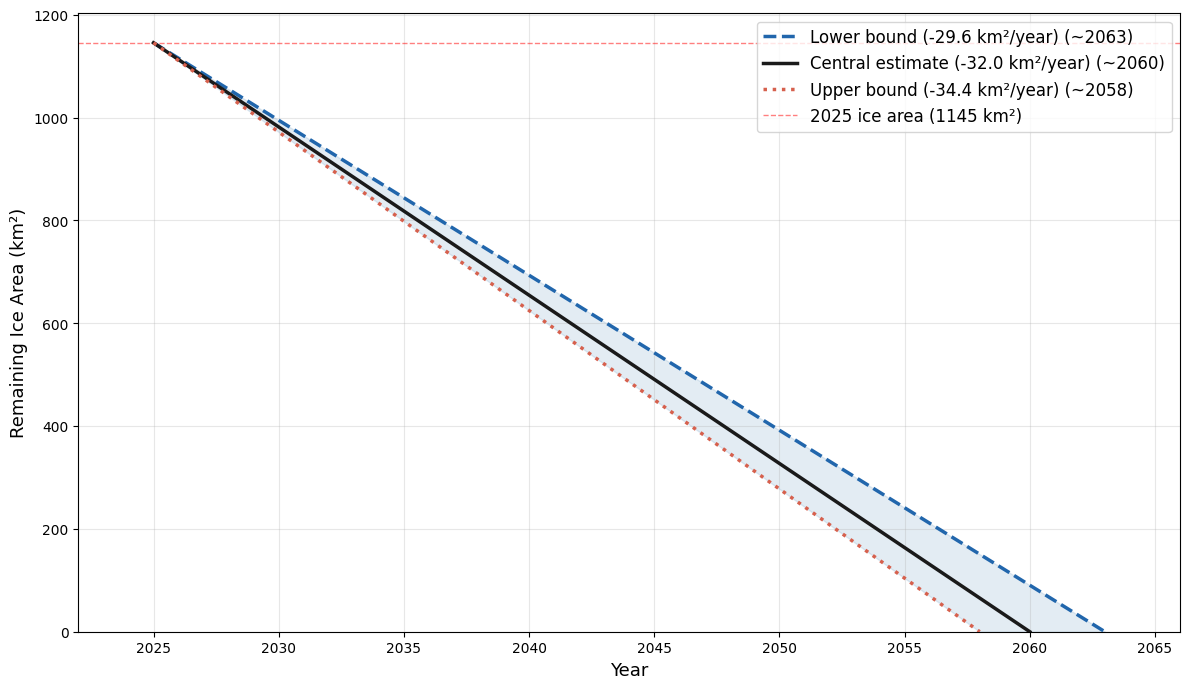

In [16]:
fig, ax = plt.subplots(figsize=(12, 7))

SCENARIO_STYLES = {
    'Lower bound (-29.6 km²/year)': {
        'color': '#2166ac', 'linestyle': '--'
    },
    'Central estimate (-32.0 km²/year)': {
        'color': '#1a1a1a', 'linestyle': '-'
    },
    'Upper bound (-34.4 km²/year)': {
        'color': '#d6604d', 'linestyle': ':'
    },
}

# Compute deglaciation years cleanly
deglac_years = {}
for name in SCENARIOS:
    annual_rate = SCENARIOS[name]  # km²/year
    deglac_years[name] = int(2025 + start_area / annual_rate)

print("Deglaciation years:")
for name, year in deglac_years.items():
    print(f"  {name}: {year}")

# Uncertainty envelope
x_lower = [2025, deglac_years['Lower bound (-29.6 km²/year)']]
y_lower = [start_area, 0]
x_upper = [2025, deglac_years['Upper bound (-34.4 km²/year)']]
y_upper = [start_area, 0]

x_fill  = np.linspace(2025, deglac_years['Lower bound (-29.6 km²/year)'], 500)
y_lo    = np.clip(np.interp(x_fill, x_lower, y_lower), 0, None)
y_hi    = np.clip(np.interp(x_fill, x_upper, y_upper), 0, None)

ax.fill_between(x_fill, y_lo, y_hi,
                alpha=0.15, color='steelblue')

# Plot straight lines
for name, style in SCENARIO_STYLES.items():
    deglac = deglac_years[name]
    ax.plot([2025, deglac], [start_area, 0],
            color=style['color'],
            linestyle=style['linestyle'],
            linewidth=2.5,
            label=f"{name} (~{deglac})",
            zorder=3)


ax.axhline(y=start_area, color='red', linestyle='--',
           alpha=0.5, linewidth=1,
           label=f'2025 ice area ({start_area:.0f} km²)')

ax.set_xlabel('Year', fontsize=13)
ax.set_ylabel('Remaining Ice Area (km²)', fontsize=13)
ax.set_ylim(bottom=0)
ax.set_xlim(2022, deglac_years['Lower bound (-29.6 km²/year)'] + 3)
ax.legend(fontsize=12, loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_xticks(range(2025, deglac_years['Lower bound (-29.6 km²/year)'] + 5, 5))

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'glacier_retreat_projection.png',
            dpi=200, bbox_inches='tight')
plt.show()

In [44]:
# Save all scenario area histories
rows = []
for name, area_history in scenario_results.items():
    for year, area in area_history:
        rows.append({
            'scenario':      name,
            'year':          year,
            'ice_area_km2':  area,
            'ice_loss_km2':  start_area - area,
            'ice_loss_pct':  (start_area - area) / start_area * 100
        })

df_history = pd.DataFrame(rows)
df_history.to_parquet(
    RESULTS_DIR / 'simulation_area_history.parquet', index=False)
print("Saved simulation_area_history.parquet")
print("\nKey results (central scenario):")
central = df_history[
    df_history['scenario'] == 'Central estimate (this study)']
print(central[['year', 'ice_area_km2', 'ice_loss_pct']].to_string(index=False))

Saved simulation_area_history.parquet

Key results (central scenario):
Empty DataFrame
Columns: [year, ice_area_km2, ice_loss_pct]
Index: []
